# DATA 620 Assignment 3: Graph Visualization

## Facebook Social Network Analysis

**Sachi Kapoor**

### Introduction

This project analyzes the Facebook Social Circles dataset from the Stanford Network Analysis Project, also known as SNAP. The dataset represents anonymized Facebook friendships. Each node represents a Facebook user, and each edge represents a friendship between two users.

Because Facebook friendships are mutual, the network is modeled as an undirected graph. The analysis examines the network's size, connectivity, diameter, density, clustering, average degree, and degree centrality. A subset of the network is also visualized to show the structure surrounding its most connected user.

**Dataset source:** https://snap.stanford.edu/data/ego-Facebook.html

In [1]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
G = nx.read_edgelist(
    "facebook_combined.txt.gz",
    nodetype=int,
    create_using=nx.Graph()
)

print("The dataset was loaded successfully.")
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())
print("Is the graph connected?", nx.is_connected(G))

The dataset was loaded successfully.
Number of nodes: 4039
Number of edges: 88234
Is the graph connected? True


In [3]:
diameter = nx.diameter(G)

print("Graph diameter:", diameter)

Graph diameter: 8


### Graph Diameter

The diameter of the Facebook network is 8. Diameter represents the longest shortest path between any two users in the network. This means that even the two most distant users can be connected through no more than eight friendship connections.

In [4]:
density = nx.density(G)
average_clustering = nx.average_clustering(G)
average_degree = sum(dict(G.degree()).values()) / G.number_of_nodes()

print("Network density:", round(density, 4))
print("Average clustering coefficient:", round(average_clustering, 4))
print("Average degree:", round(average_degree, 2))

Network density: 0.0108
Average clustering coefficient: 0.6055
Average degree: 43.69


### Additional Network Metrics

The network density is approximately 0.0108, meaning that about 1.08 percent of all possible friendship connections are present. This low density is reasonable because each Facebook user is connected to only a small portion of all users in the network.

The average clustering coefficient is approximately 0.6055. This indicates that many users' friends are also friends with one another, suggesting the presence of closely connected social groups.

The average degree is approximately 43.69, meaning that each user has about 44 friendship connections on average within this dataset.

In [5]:
degree_centrality = nx.degree_centrality(G)

centrality_df = pd.DataFrame(
    degree_centrality.items(),
    columns=["Node", "Degree Centrality"]
)

centrality_df["Degree"] = centrality_df["Node"].map(dict(G.degree()))

centrality_df = centrality_df.sort_values(
    by="Degree Centrality",
    ascending=False
)

centrality_df.head(10)

,Node,Degree Centrality,Degree
107,107,0.258791,1045
351,1684,0.196137,792
352,1912,0.186974,755
1821,3437,0.135463,547
0,0,0.085934,347
1490,2543,0.072808,294
2154,2347,0.072065,291
1373,1888,0.062902,254
1285,1800,0.060674,245
1149,1663,0.058197,235


### Degree Centrality

Degree centrality measures how directly connected each user is within the network. A user with higher degree centrality has more direct friendship connections and may occupy a more influential or central position in the network. Since the user identities are anonymized, the nodes are identified using numerical IDs.

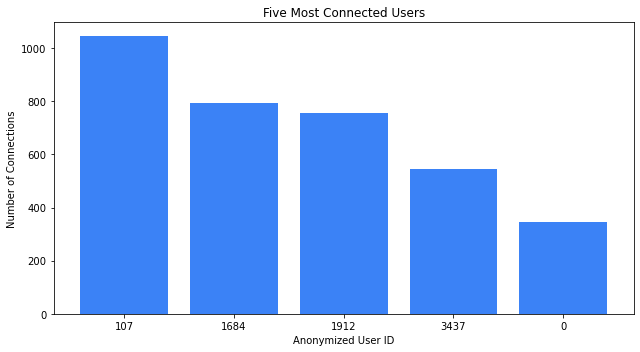

In [6]:
top_five = centrality_df.head(5).copy()

plt.figure(figsize=(9, 5))

plt.bar(
    top_five["Node"].astype(str),
    top_five["Degree"],
    color="#3b82f6"
)

plt.title("Five Most Connected Users")
plt.xlabel("Anonymized User ID")
plt.ylabel("Number of Connections")
plt.tight_layout()

plt.savefig(
    "top_five_connected_users.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [7]:
# Identify the most connected user
most_connected_node = max(G.degree, key=lambda item: item[1])[0]

# Select 149 of that user's most-connected friends
top_neighbors = sorted(
    G.neighbors(most_connected_node),
    key=lambda node: G.degree(node),
    reverse=True
)[:149]

# Create a connected visualization subset
selected_nodes = [most_connected_node] + top_neighbors
visualization_graph = G.subgraph(selected_nodes).copy()

print("Central user:", most_connected_node)
print("Central user's total connections:", G.degree[most_connected_node])
print("Nodes displayed:", visualization_graph.number_of_nodes())
print("Edges displayed:", visualization_graph.number_of_edges())

Central user: 107
Central user's total connections: 1045
Nodes displayed: 150
Edges displayed: 6311


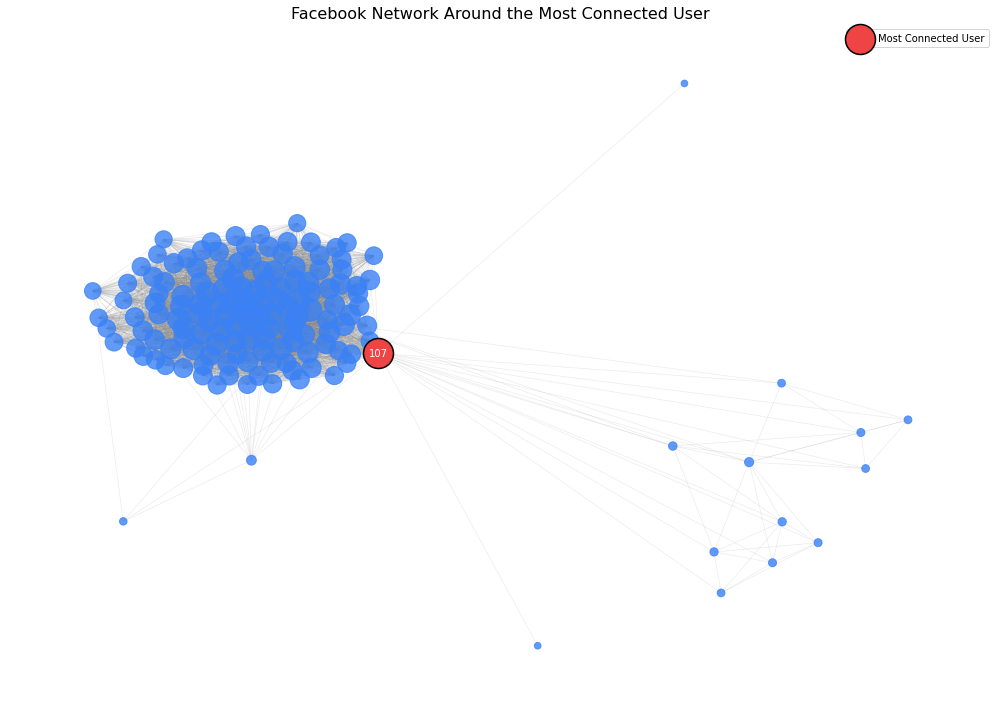

In [8]:
plt.figure(figsize=(14, 10))

position = nx.spring_layout(
    visualization_graph,
    seed=42,
    k=0.35,
    iterations=75
)

other_nodes = [
    node for node in visualization_graph.nodes()
    if node != most_connected_node
]

other_node_sizes = [
    40 + visualization_graph.degree(node) * 4
    for node in other_nodes
]

nx.draw_networkx_edges(
    visualization_graph,
    position,
    alpha=0.15,
    width=0.7,
    edge_color="gray"
)

nx.draw_networkx_nodes(
    visualization_graph,
    position,
    nodelist=other_nodes,
    node_size=other_node_sizes,
    node_color="#3b82f6",
    alpha=0.80
)

nx.draw_networkx_nodes(
    visualization_graph,
    position,
    nodelist=[most_connected_node],
    node_size=900,
    node_color="#ef4444",
    edgecolors="black",
    linewidths=1.5,
    label="Most Connected User"
)

nx.draw_networkx_labels(
    visualization_graph,
    position,
    labels={most_connected_node: str(most_connected_node)},
    font_size=10,
    font_color="white"
)

plt.title(
    "Facebook Network Around the Most Connected User",
    fontsize=16
)
plt.legend()
plt.axis("off")
plt.tight_layout()

plt.savefig(
    "facebook_network_visualization.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Network Visualization

The visualization displays the most connected user and 149 of that user's most-connected friends. The red node represents anonymized user 107, who has the highest degree in the full network. The blue nodes represent connected users, and larger blue nodes have more connections within the displayed subset.

A subset was used because displaying all 4,039 users and 88,234 edges would make the visualization difficult to interpret. The graph demonstrates how a highly connected user can function as a central hub within a social network.

## Conclusion

This analysis examined an anonymized Facebook friendship network containing 4,039 users and 88,234 friendship connections. The network is connected and has a diameter of 8, meaning that even the two most distant users can be connected through no more than eight friendship links.

Although only about 1.08 percent of all possible connections are present, the average clustering coefficient of 0.6055 shows that users tend to form closely connected social groups. Each user has approximately 44 connections on average. Degree centrality identified user 107 as the most connected user, with 1,045 direct connections.

The visualizations make these findings easier to interpret. The bar chart compares the five most connected users, while the network graph shows how user 107 functions as a central hub. Overall, the analysis demonstrates how graph metrics and visualization can reveal connectivity, influential users, and social structure within an online network.